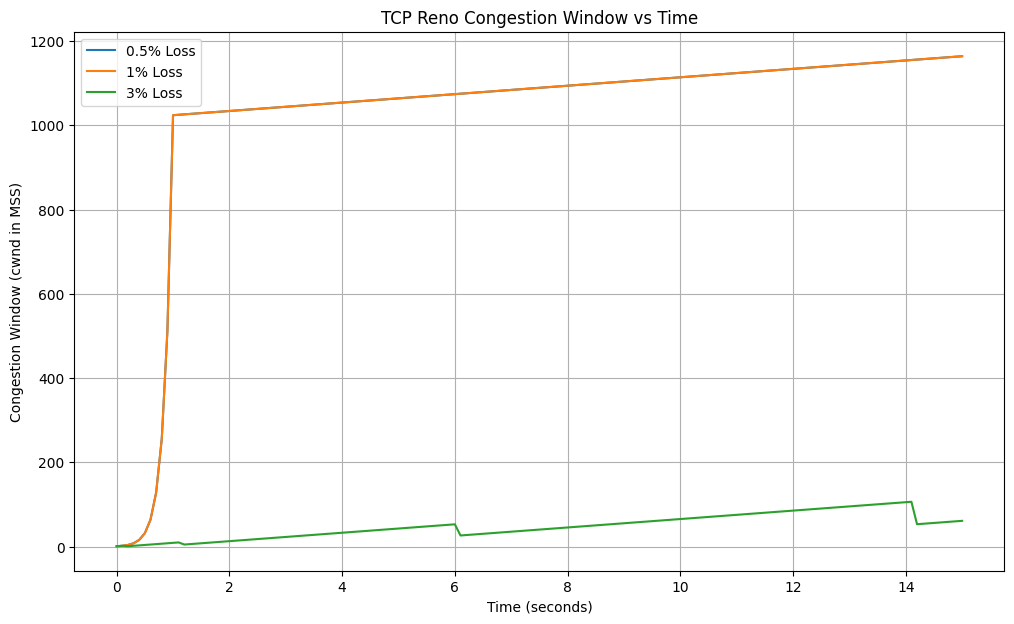

In [9]:
import random
import matplotlib.pyplot as plt

# ---------------------------------------
# TCP Reno Simulation Function
# ---------------------------------------
def simulate_tcp_reno(loss_prob, total_time=15, rtt=0.1):
    """
    Simulates TCP Reno cwnd behavior.
    loss_prob: probability of packet loss (0.005, 0.01, 0.03)
    total_time: total simulation time (seconds)
    rtt: round-trip time (100 ms default)
    """
    time_points = []
    cwnd_points = []

    cwnd = 1            # Start with 1 MSS
    ssthresh = 1000     # Very high initial threshold
    t = 0

    while t < total_time:
        time_points.append(t)
        cwnd_points.append(cwnd)

        # Random packet loss simulation
        if random.random() < loss_prob:
            # Multiplicative decrease on loss
            ssthresh = cwnd / 2
            cwnd = max(1, cwnd / 2)
        else:
            # TCP Reno growth rules
            if cwnd < ssthresh:
                cwnd *= 2     # Slow Start (exponential)
            else:
                cwnd += 1     # Congestion Avoidance (linear)

        t += rtt  # Increase time per RTT

    return time_points, cwnd_points


# ---------------------------------------
# Run Simulation for 3 Loss Cases
# ---------------------------------------
loss_cases = {
    "0.5% Loss": 0.005,
    "1% Loss": 0.01,
    "3% Loss": 0.03
}

plt.figure(figsize=(12, 7))

for label, loss in loss_cases.items():
    t, cw = simulate_tcp_reno(loss)
    plt.plot(t, cw, label=label)

plt.title("TCP Reno Congestion Window vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Congestion Window (cwnd in MSS)")
plt.grid(True)
plt.legend()
plt.show()
